# TD-3 Exploratory Data Analysis: Hotel Booking Cancellations

This practical session is based on **CM3 — Exploratory Data Analysis (EDA)**.

In TD1 and TD2, the main objective was to learn how to manipulate, inspect, clean, and preprocess data.  
In this TD, the objective is different: you must use Python to **investigate a real question**, produce evidence with tables and visualizations, and explain what the observations may mean.

We use the **Hotel Booking Demand** dataset. Each row corresponds to one hotel booking.

Main question:

> **What factors seem to be associated with hotel booking cancellations, and how do these patterns differ between City Hotel and Resort Hotel?**

Important: in EDA, we study **associations**, not direct causal effects.

This is the **complete correction version** of the notebook.


## Session plan

During this session, you will work through a problem-driven EDA workflow:

1. Load the dataset and understand the unit of analysis  
2. Inspect data quality and perform light cleaning  
3. Create useful variables for analysis  
4. Measure the global cancellation rate  
5. Compare cancellation patterns by hotel type  
6. Study the relationship between lead time and cancellation  
7. Analyze categorical factors such as market segment, deposit type, and customer type  
8. Study seasonality and price patterns  
9. Synthesize findings, explanations, business implications, and limitations

Expected final output: a notebook with code, visualizations, and written interpretations.


In [31]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")

## Part 0 — Load the dataset

We use a CSV version of the Hotel Booking Demand dataset hosted by the TidyTuesday project.

### Tasks
1. Load the dataset into a dataframe called `hotels_df`.
2. Display the first 5 rows.
3. Display the shape of the dataset.
4. Create a working copy called `df`.


In [32]:
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2020/2020-02-11/hotels.csv"

hotels_df = pd.read_csv(url)
hotels_df.head()
hotels_df.shape

df = hotels_df.copy()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


(119390, 32)

## Part 1 — First inspection of the dataset

Before answering the main question, we must understand the structure of the data.

### Tasks
1. Display general information about `df`.
2. Show the data types of all columns.
3. Display numerical summaries.
4. Display categorical summaries.
5. Identify the meaning of the target variable `is_canceled`.


In [33]:
df.info()

df.dtypes

df.describe()

df.describe(include="object")

df["is_canceled"].value_counts()
df["is_canceled"].value_counts(normalize=True).round(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3,926
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2015-10-21
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166,1461


is_canceled
0    75166
1    44224
Name: count, dtype: int64

is_canceled
0    0.63
1    0.37
Name: proportion, dtype: float64

Each row in this dataset represents one hotel booking/reservation.

Why is this important for our analysis?

In particular, when we compute:

`df["is_canceled"].mean()`
what are we measuring?

**Short comment:**  
Each row represents one booking/reservation, not one customer, one hotel, or one night.
Therefore, `df["is_canceled"].mean()` measures the proportion of bookings that were canceled.
It should not be interpreted as the proportion of customers who canceled, because the same customer or group may appear in multiple bookings.


## Part 2 — Data quality and light cleaning

The goal of this TD is not to build a full preprocessing pipeline. However, EDA still requires basic cleaning decisions.

### Tasks
1. Count missing values.
2. Compute the percentage of missing values.
3. Inspect columns with missing values.
4. Apply reasonable simple cleaning choices.


In [34]:
missing_count = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False).round(4)

missing_table = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct
})

missing_table[missing_table["missing_count"] > 0]

,missing_count,missing_pct
company,112593,94.3069
agent,16340,13.6862
country,488,0.4087
children,4,0.0034


### Cleaning decisions

For this lab, use the following simple decisions:

- Missing `children` values are replaced by `0`.
- Missing `country` values are replaced by `"Unknown"`.
- Missing `agent` values are replaced by `"No agent"`.
- Missing `company` values are replaced by `"No company"`.

These choices are not universal rules. They are assumptions made for this EDA.


In [35]:
df["children"] = df["children"].fillna(0)
df["country"] = df["country"].fillna("Unknown")
df["agent"] = df["agent"].fillna("No agent")
df["company"] = df["company"].fillna("No company")

df[["children", "country", "agent", "company"]].isna().sum()

children    0
country     0
agent       0
company     0
dtype: int64

Why is it dangerous to automatically drop all rows with missing values?

**Short comment:**  
Dropping all rows with missing values would remove too much data, especially because `company` is missing for more than 94% of the bookings. 
For `agent` and `company`, missing values may indicate that the booking was not associated with an agent or a company, but this is an assumption. 

For this EDA, we keep this information by replacing missing values with explicit categories such as `"No agent"` and `"No company"`.


## Part 3 — Create useful variables for EDA

EDA often requires creating variables that are easier to interpret than the original columns.

### Tasks
Create the following variables:

1. `total_nights` = weekend nights + week nights
2. `total_guests` = adults + children + babies
3. `has_children` = whether the booking includes children or babies
4. Convert `arrival_date_month` into an ordered categorical variable


In [36]:
df["total_nights"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]
df["total_guests"] = df["adults"] + df["children"] + df["babies"]
df["has_children"] = (df["children"] + df["babies"] > 0)

month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

df["arrival_date_month"] = pd.Categorical(
    df["arrival_date_month"],
    categories=month_order,
    ordered=True
)

In [37]:
df[[
    "stays_in_weekend_nights", "stays_in_week_nights", "total_nights",
    "adults", "children", "babies", "total_guests", "has_children",
    "arrival_date_month"
]].head()

,stays_in_weekend_nights,stays_in_week_nights,total_nights,adults,children,babies,total_guests,has_children,arrival_date_month
0,0,0,0,2,0.0,0,2.0,False,July
1,0,0,0,2,0.0,0,2.0,False,July
2,0,1,1,1,0.0,0,1.0,False,July
3,0,1,1,1,0.0,0,1.0,False,July
4,0,2,2,2,0.0,0,2.0,False,July


Why are these new variables more convenient for EDA?

**Short comment:**  
The new variables summarize information that is spread across several columns. For example, `total_nights` is easier to interpret than separately checking weekend nights and week nights. `has_children` is also useful because many analyses compare family and non-family bookings rather than exact numbers of children.


## Part 4 — Global cancellation pattern

We start with the simplest question: how frequent are cancellations?

### Tasks
1. Compute the global cancellation rate.
2. Plot the number of canceled and non-canceled bookings.
3. Interpret the result.


In [38]:
cancel_rate = df["is_canceled"].mean()
cancel_rate

0.37041628277075134

<Figure size 600x400 with 0 Axes>

<Axes: xlabel='is_canceled', ylabel='count'>

Text(0.5, 1.0, 'Number of canceled and non-canceled bookings')

Text(0.5, 0, 'Canceled (0 = no, 1 = yes)')

Text(0, 0.5, 'Number of bookings')

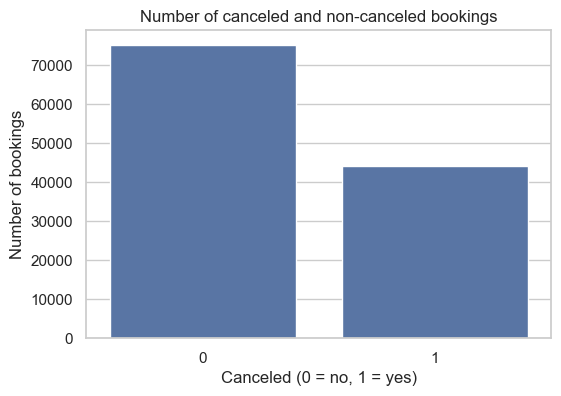

In [39]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="is_canceled")
plt.title("Number of canceled and non-canceled bookings")
plt.xlabel("Canceled (0 = no, 1 = yes)")
plt.ylabel("Number of bookings")
plt.show()

**Questions:**
1. Is cancellation a rare event in this dataset?
2. Why does this matter for hotels?

**Interpretation:**  
The global cancellation rate is about 37.0%, meaning that more than one third of the bookings were canceled. 
Therefore, cancellation is not a rare event in this dataset. 

This matters for hotels because cancellations directly affect revenue forecasting, room availability, staffing, and overbooking strategies.


## Part 5 — Cancellation by hotel type

We now compare City Hotel and Resort Hotel.

### Tasks
1. Compute the cancellation rate by hotel type.
2. Plot the result.
3. Explain whether the observed difference can be interpreted causally.


In [40]:
hotel_cancel = (
    df.groupby("hotel")["is_canceled"]
    .agg(cancellation_rate="mean", num_bookings="count")
    .reset_index()
)

hotel_cancel

,hotel,cancellation_rate,num_bookings
0,City Hotel,0.417270,79330
1,Resort Hotel,0.277634,40060


<Figure size 700x400 with 0 Axes>

<Axes: xlabel='hotel', ylabel='cancellation_rate'>

Text(0.5, 1.0, 'Cancellation rate by hotel type')

Text(0.5, 0, 'Hotel type')

Text(0, 0.5, 'Cancellation rate')

(0.0, 0.5)

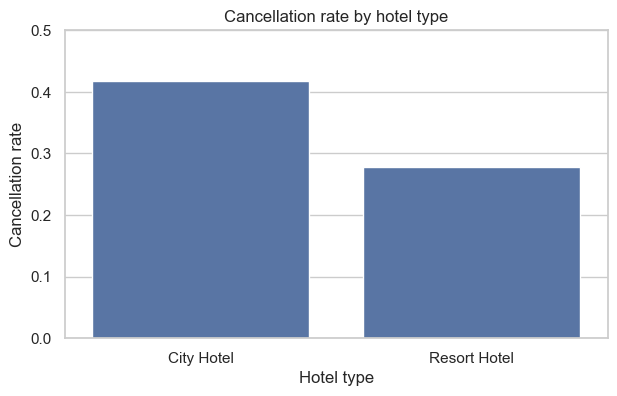

In [41]:
plt.figure(figsize=(7, 4))
sns.barplot(data=hotel_cancel, x="hotel", y="cancellation_rate")
plt.title("Cancellation rate by hotel type")
plt.xlabel("Hotel type")
plt.ylabel("Cancellation rate")
plt.ylim(0, 0.5)
plt.show()

**Questions:**
1. Which hotel type has the higher cancellation rate?
2. Does this prove that hotel type causes cancellation? Why or why not?
3. What other variables may explain the difference?
   
**Interpretation:**  
City Hotel has a higher cancellation rate than Resort Hotel: about 41.7% compared with 27.8%. 

This is a clear descriptive difference, but it does not prove that the hotel type itself causes cancellations. 

The two hotels may differ in customer profiles, market segments, booking channels, lead time, prices, and seasonal patterns.

## Part 6 — Lead time and cancellation

`lead_time` is the number of days between the booking date and the arrival date. This is likely to be an important variable.

### Tasks
1. Plot the distribution of `lead_time`.
2. Create lead time groups.
3. Compute and plot cancellation rate by lead time group.
4. Compare this pattern by hotel type.


<Figure size 800x400 with 0 Axes>

<Axes: xlabel='lead_time', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of lead time')

Text(0.5, 0, 'Lead time in days')

Text(0, 0.5, 'Number of bookings')

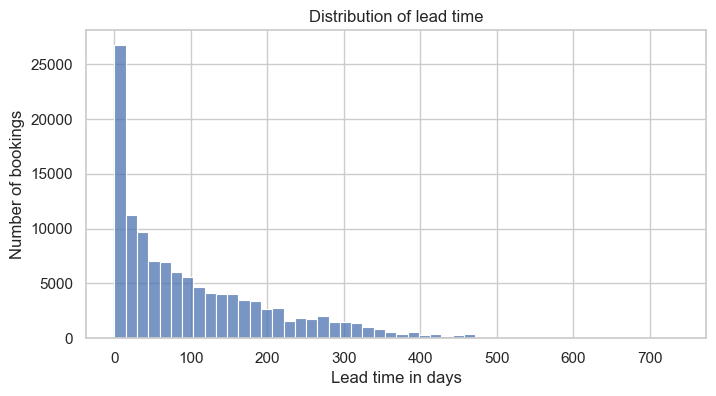

In [42]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="lead_time", bins=50)
plt.title("Distribution of lead time")
plt.xlabel("Lead time in days")
plt.ylabel("Number of bookings")
plt.show()

In [43]:
bins = [0, 7, 30, 90, 180, 365, df["lead_time"].max()]
labels = ["0-7", "8-30", "31-90", "91-180", "181-365", "365+"]

df["lead_time_group"] = pd.cut(
    df["lead_time"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df["lead_time_group"].value_counts().sort_index()

lead_time_group
0-7        19746
8-30       18960
31-90      29553
91-180     26439
181-365    21544
365+        3148
Name: count, dtype: int64

,lead_time_group,cancellation_rate,num_bookings
0,0-7,0.096323,19746
1,8-30,0.278639,18960
2,31-90,0.376984,29553
3,91-180,0.447105,26439
4,181-365,0.554540,21544
5,365+,0.676620,3148


<Figure size 800x400 with 0 Axes>

<Axes: xlabel='lead_time_group', ylabel='cancellation_rate'>

Text(0.5, 1.0, 'Cancellation rate by lead time group')

Text(0.5, 0, 'Lead time group')

Text(0, 0.5, 'Cancellation rate')

(0.0, 1.0)

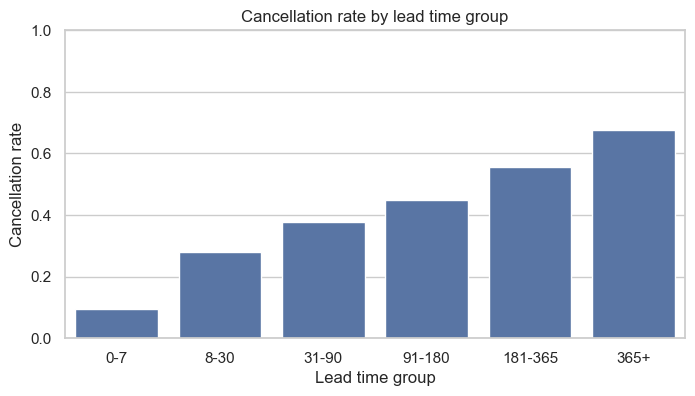

In [44]:
lead_cancel = (
    df.groupby("lead_time_group", observed=False)["is_canceled"]
    .agg(cancellation_rate="mean", num_bookings="count")
    .reset_index()
)

lead_cancel

plt.figure(figsize=(8, 4))
sns.barplot(data=lead_cancel, x="lead_time_group", y="cancellation_rate")
plt.title("Cancellation rate by lead time group")
plt.xlabel("Lead time group")
plt.ylabel("Cancellation rate")
plt.ylim(0, 1)
plt.show()

<Figure size 900x400 with 0 Axes>

<Axes: xlabel='lead_time_group', ylabel='cancellation_rate'>

Text(0.5, 1.0, 'Cancellation rate by lead time group and hotel type')

Text(0.5, 0, 'Lead time group')

Text(0, 0.5, 'Cancellation rate')

(0.0, 1.0)

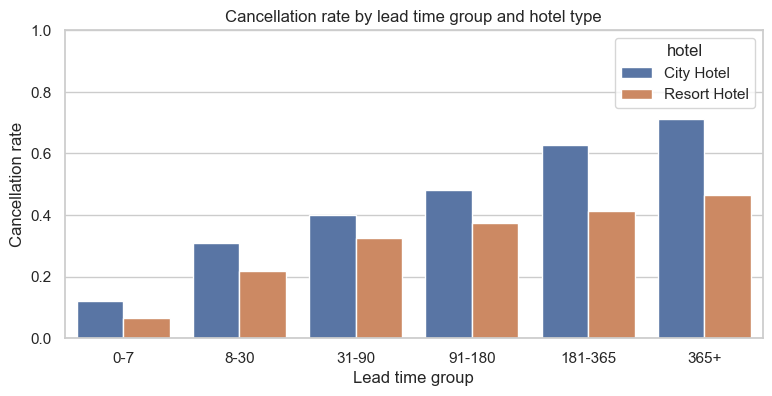

In [45]:
lead_hotel_cancel = (
    df.groupby(["hotel", "lead_time_group"], observed=False)["is_canceled"]
    .agg(cancellation_rate="mean", num_bookings="count")
    .reset_index()
)

plt.figure(figsize=(9, 4))
sns.barplot(
    data=lead_hotel_cancel,
    x="lead_time_group",
    y="cancellation_rate",
    hue="hotel"
)
plt.title("Cancellation rate by lead time group and hotel type")
plt.xlabel("Lead time group")
plt.ylabel("Cancellation rate")
plt.ylim(0, 1)
plt.show()

**Questions:**
1. Does cancellation rate increase with lead time?
2. Is the pattern the same for both hotel types?
3. What possible explanations can you propose?
   
**Interpretation:**  
Cancellation rate increases strongly with lead time. 
Bookings made within 0–7 days have a cancellation rate below 10%, whereas bookings made more than one year in advance have a cancellation rate above 67%.

The increasing trend appears for both hotel types, but the level is not the same. 
City Hotel has a higher cancellation rate than Resort Hotel in every lead-time group, and the difference becomes particularly visible for long lead times. 

A possible explanation is that plans made far in advance are more likely to change, but lead time may also be correlated with market segment, deposit type, customer type, or hotel type.


## Part 7 — Categorical factors: market segment, deposit type, and customer type

EDA should compare groups, but we must always check both the rate and the number of observations.

### Categorical factors

In this part, we study three categorical variables:

- `market_segment`: how the booking reached the hotel, for example direct booking, online travel agency, corporate client, or group booking.
- `deposit_type`: the deposit condition of the booking, for example no deposit, non-refundable deposit, or refundable deposit.
- `customer_type`: the type of customer or booking, for example transient individual customer, group, or contract customer.

These variables are useful because they describe the context of the booking.  
They may help us understand why some bookings are more likely to be canceled than others.

### Tasks
1. Compute cancellation rate and sample size by `market_segment`.
2. Compute cancellation rate and sample size by `deposit_type`.
3. Compute cancellation rate and sample size by `customer_type`.
4. Interpret the results carefully.


,cancellation_rate,num_bookings
market_segment,,
Undefined,1.000000,2
Groups,0.610620,19811
Online TA,0.367211,56477
Offline TA/TO,0.343160,24219
Aviation,0.219409,237
Corporate,0.187347,5295
Direct,0.153419,12606
Complementary,0.130552,743


<Figure size 800x400 with 0 Axes>

<Axes: xlabel='cancellation_rate', ylabel='market_segment'>

Text(0.5, 1.0, 'Cancellation rate by market segment')

Text(0.5, 0, 'Cancellation rate')

Text(0, 0.5, 'Market segment')

(0.0, 1.0)

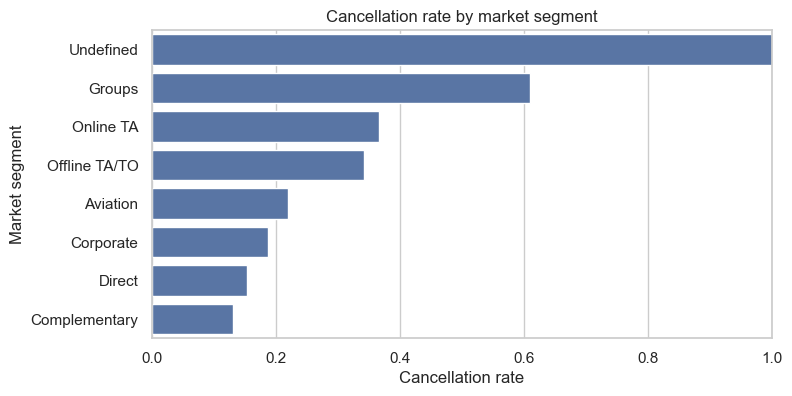

In [46]:
segment_cancel = (
    df.groupby("market_segment")["is_canceled"]
    .agg(cancellation_rate="mean", num_bookings="count")
    .sort_values("cancellation_rate", ascending=False)
)

segment_cancel

plt.figure(figsize=(8, 4))
sns.barplot(
    data=segment_cancel.reset_index(),
    x="cancellation_rate",
    y="market_segment"
)
plt.title("Cancellation rate by market segment")
plt.xlabel("Cancellation rate")
plt.ylabel("Market segment")
plt.xlim(0, 1)
plt.show()

The `Undefined` category has a cancellation rate of 100%, but it contains only 2 bookings, so it should not be interpreted.

Among categories with substantial sample size, `Groups` has the highest cancellation rate, around 61.1%. 

Online TA and Offline TA/TO also show relatively high cancellation rates, while Direct and Corporate bookings have lower cancellation rates.

This suggests that the booking channel or market context is strongly associated with cancellation behavior.

,cancellation_rate,num_bookings
deposit_type,,
Non Refund,0.993624,14587
No Deposit,0.283770,104641
Refundable,0.222222,162


<Figure size 700x400 with 0 Axes>

<Axes: xlabel='deposit_type', ylabel='cancellation_rate'>

Text(0.5, 1.0, 'Cancellation rate by deposit type')

Text(0.5, 0, 'Deposit type')

Text(0, 0.5, 'Cancellation rate')

(0.0, 1.0)

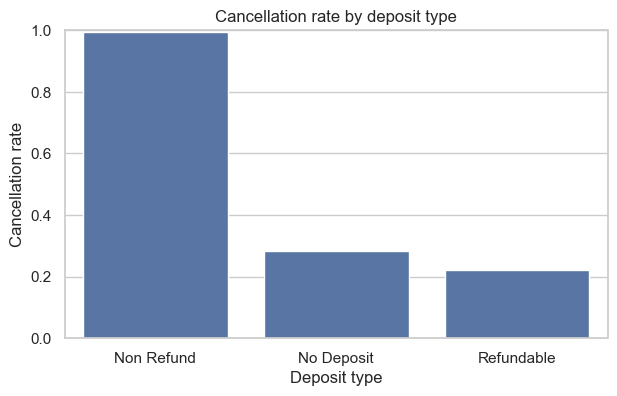

In [47]:
deposit_cancel = (
    df.groupby("deposit_type")["is_canceled"]
    .agg(cancellation_rate="mean", num_bookings="count")
    .sort_values("cancellation_rate", ascending=False)
)

deposit_cancel

plt.figure(figsize=(7, 4))
sns.barplot(
    data=deposit_cancel.reset_index(),
    x="deposit_type",
    y="cancellation_rate"
)
plt.title("Cancellation rate by deposit type")
plt.xlabel("Deposit type")
plt.ylabel("Cancellation rate")
plt.ylim(0, 1)
plt.show()

The result for `deposit_type` is highly counter-intuitive. Bookings with `Non Refund` deposit have an extremely high cancellation rate, about 99.4%, although non-refundable conditions would normally be expected to discourage cancellation.

This does not mean that non-refundable deposits cause cancellations. 

Further checks show that `Non Refund` bookings are not distributed like ordinary bookings: they are mainly associated with `Groups` and `Offline TA/TO`, they have much longer lead times, and they are mostly City Hotel bookings. 

Therefore, `deposit_type` is likely confounded with market segment, lead time, and hotel type. 

In this dataset, `Non Refund` may act more like a marker of a specific high-risk booking context than a simple deposit policy.

In [ ]:
deposit_segment = pd.crosstab(
    df["deposit_type"],
    df["market_segment"],
    normalize="index"
)

deposit_segment

market_segment,Aviation,Complementary,Corporate,Direct,Groups,Offline TA/TO,Online TA,Undefined
deposit_type,,,,,,,,
No Deposit,0.002265,0.0071,0.047371,0.120230,0.100429,0.183570,0.539014,0.000019
Non Refund,0.000000,0.0000,0.022897,0.001303,0.628779,0.343182,0.003839,0.000000
Refundable,0.000000,0.0000,0.024691,0.037037,0.802469,0.024691,0.111111,0.000000


In [ ]:
deposit_customer = pd.crosstab(
    df["deposit_type"],
    df["customer_type"],
    normalize="index"
)

deposit_customer

customer_type,Contract,Group,Transient,Transient-Party
deposit_type,,,,
No Deposit,0.033734,0.005438,0.732829,0.227999
Non Refund,0.037293,0.000000,0.884966,0.077740
Refundable,0.012346,0.049383,0.123457,0.814815


In [ ]:
df.groupby("deposit_type")["lead_time"].agg(["count", "mean", "median", "min", "max"])

,count,mean,median,min,max
deposit_type,,,,,
No Deposit,104641,88.756615,56.0,0,737
Non Refund,14587,212.908891,183.0,0,629
Refundable,162,152.098765,169.0,0,385


In [ ]:
pd.crosstab(
    df["deposit_type"],
    df["hotel"],
    normalize="index"
)

hotel,City Hotel,Resort Hotel
deposit_type,,
No Deposit,0.634952,0.365048
Non Refund,0.882155,0.117845
Refundable,0.123457,0.876543


,cancellation_rate,num_bookings
customer_type,,
Transient,0.407463,89613
Contract,0.309617,4076
Transient-Party,0.254299,25124
Group,0.102253,577


<Figure size 800x400 with 0 Axes>

<Axes: xlabel='cancellation_rate', ylabel='customer_type'>

Text(0.5, 1.0, 'Cancellation rate by customer type')

Text(0.5, 0, 'Cancellation rate')

Text(0, 0.5, 'Customer type')

(0.0, 1.0)

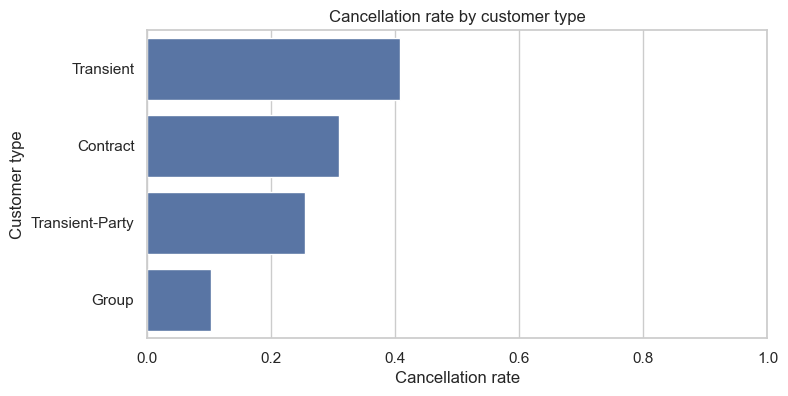

In [48]:
customer_cancel = (
    df.groupby("customer_type")["is_canceled"]
    .agg(cancellation_rate="mean", num_bookings="count")
    .sort_values("cancellation_rate", ascending=False)
)

customer_cancel

plt.figure(figsize=(8, 4))
sns.barplot(
    data=customer_cancel.reset_index(),
    x="cancellation_rate",
    y="customer_type"
)
plt.title("Cancellation rate by customer type")
plt.xlabel("Cancellation rate")
plt.ylabel("Customer type")
plt.xlim(0, 1)
plt.show()

`Transient` customers have the highest cancellation rate, around 40.7%, and they also represent the largest customer category. 

`Transient-Party` and `Contract` bookings have lower cancellation rates, while `Group` has the lowest cancellation rate. 

However, the `Group` customer type contains only 577 bookings, so it should be interpreted carefully.

## Part 8 — Seasonality and time patterns

Hotel demand is often seasonal. We now analyze bookings and cancellations by arrival month.

### Tasks
1. Plot the number of bookings by arrival month and hotel type.
2. Plot the cancellation rate by arrival month and hotel type.
3. Interpret the differences between City Hotel and Resort Hotel.


<Figure size 1100x400 with 0 Axes>

<Axes: xlabel='arrival_date_month', ylabel='num_bookings'>

Text(0.5, 1.0, 'Number of bookings by arrival month')

Text(0.5, 0, 'Arrival month')

Text(0, 0.5, 'Number of bookings')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'January'),
  Text(1, 0, 'February'),
  Text(2, 0, 'March'),
  Text(3, 0, 'April'),
  Text(4, 0, 'May'),
  Text(5, 0, 'June'),
  Text(6, 0, 'July'),
  Text(7, 0, 'August'),
  Text(8, 0, 'September'),
  Text(9, 0, 'October'),
  Text(10, 0, 'November'),
  Text(11, 0, 'December')])

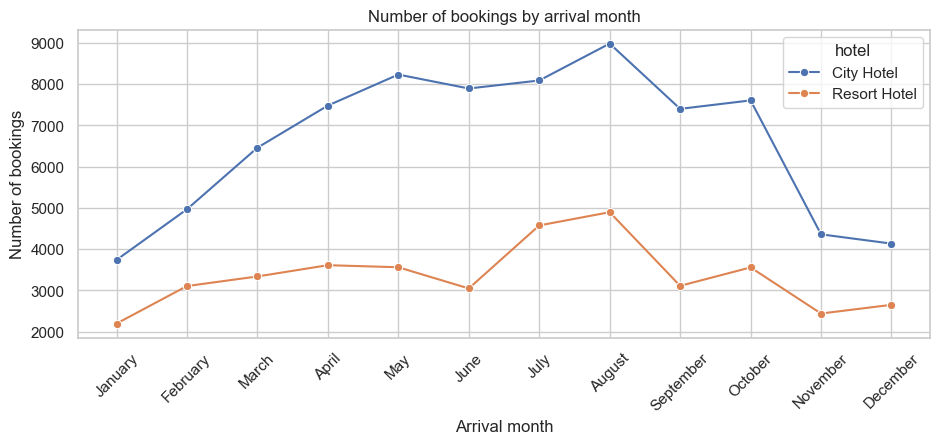

In [53]:
monthly_bookings = (
    df.groupby(["arrival_date_month", "hotel"], observed=False)
    .size()
    .reset_index(name="num_bookings")
)

plt.figure(figsize=(11, 4))
sns.lineplot(
    data=monthly_bookings,
    x="arrival_date_month",
    y="num_bookings",
    hue="hotel",
    marker="o"
)
plt.title("Number of bookings by arrival month")
plt.xlabel("Arrival month")
plt.ylabel("Number of bookings")
plt.xticks(rotation=45)
plt.show()

<Figure size 1100x400 with 0 Axes>

<Axes: xlabel='arrival_date_month', ylabel='cancellation_rate'>

Text(0.5, 1.0, 'Cancellation rate by arrival month and hotel type')

Text(0.5, 0, 'Arrival month')

Text(0, 0.5, 'Cancellation rate')

(0.0, 1.0)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'January'),
  Text(1, 0, 'February'),
  Text(2, 0, 'March'),
  Text(3, 0, 'April'),
  Text(4, 0, 'May'),
  Text(5, 0, 'June'),
  Text(6, 0, 'July'),
  Text(7, 0, 'August'),
  Text(8, 0, 'September'),
  Text(9, 0, 'October'),
  Text(10, 0, 'November'),
  Text(11, 0, 'December')])

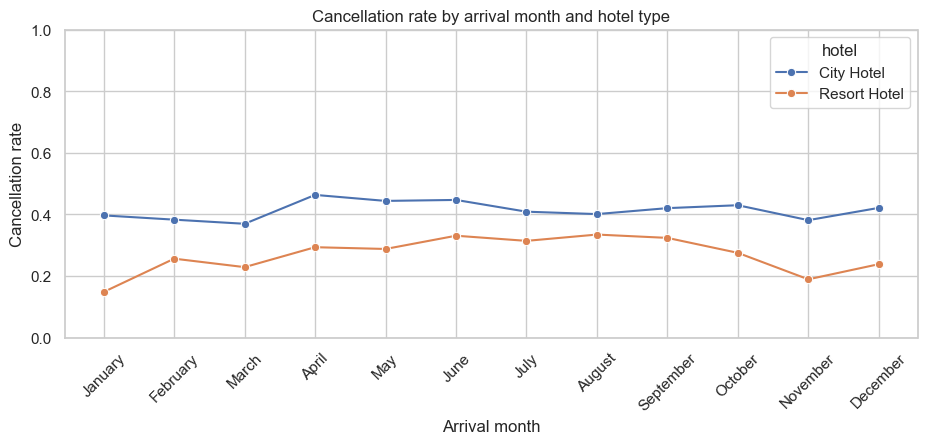

In [54]:
monthly_cancel = (
    df.groupby(["arrival_date_month", "hotel"], observed=False)["is_canceled"]
    .mean()
    .reset_index(name="cancellation_rate")
)

plt.figure(figsize=(11, 4))
sns.lineplot(
    data=monthly_cancel,
    x="arrival_date_month",
    y="cancellation_rate",
    hue="hotel",
    marker="o"
)
plt.title("Cancellation rate by arrival month and hotel type")
plt.xlabel("Arrival month")
plt.ylabel("Cancellation rate")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

**Questions:**
1. Which months have more bookings?
2. Are high-booking months also high-cancellation months?
3. Does Resort Hotel appear more seasonal than City Hotel?

**Interpretation:**  
City Hotel has more bookings than Resort Hotel in every month. Both hotels show higher booking volumes during the summer period, especially around July and August.  The Resort Hotel appears more seasonal, with a clearer summer peak, which is consistent with vacation-related demand.

The cancellation rate is also seasonal, but it does not exactly follow the booking volume. City Hotel has a higher cancellation rate than Resort Hotel in every month. For City Hotel, the highest cancellation rates appear around spring and early summer, while Resort Hotel shows relatively higher cancellation rates during the vacation season. Therefore, high booking volume does not automatically imply high cancellation rate.


## Part 9 — Price, stay duration, and cancellation

We now inspect numerical variables that may be associated with cancellations.

`adr` means **Average Daily Rate**, a measure of the average daily price of the booking.

### Tasks
1. Inspect the distribution of `adr`.
2. Filter extreme or non-positive `adr` values only for visualization.
3. Compare `adr` by cancellation status and hotel type.
4. Compare `total_nights` by cancellation status.


<Figure size 800x400 with 0 Axes>

<Axes: xlabel='hotel', ylabel='adr'>

Text(0.5, 1.0, 'ADR distribution by hotel type')

Text(0.5, 0, 'Hotel type')

Text(0, 0.5, 'ADR')

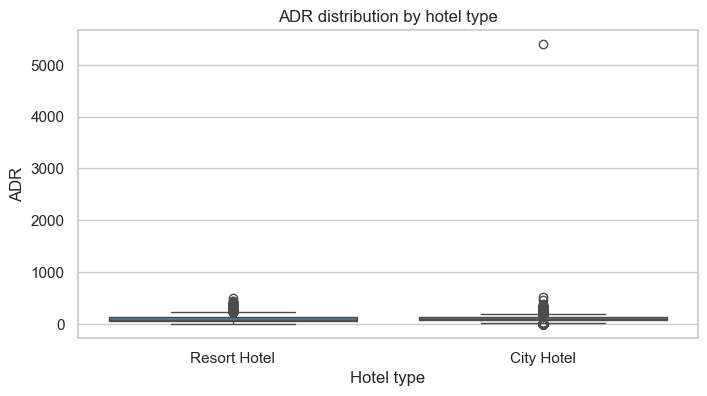

In [55]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="hotel", y="adr")
plt.title("ADR distribution by hotel type")
plt.xlabel("Hotel type")
plt.ylabel("ADR")
plt.show()

The original ADR distribution contains extreme values, including a very large value around 5400. 
Such outliers make the boxplot difficult to read because most observations are compressed near the bottom of the graph. 
For visualization only, we filter ADR values to keep positive values below 500. 
This helps us inspect the main distribution, but it should not be interpreted as a definitive data-cleaning decision.

<Figure size 800x400 with 0 Axes>

<Axes: xlabel='hotel', ylabel='adr'>

Text(0.5, 1.0, 'ADR distribution by hotel type after filtering extreme values')

Text(0.5, 0, 'Hotel type')

Text(0, 0.5, 'ADR')

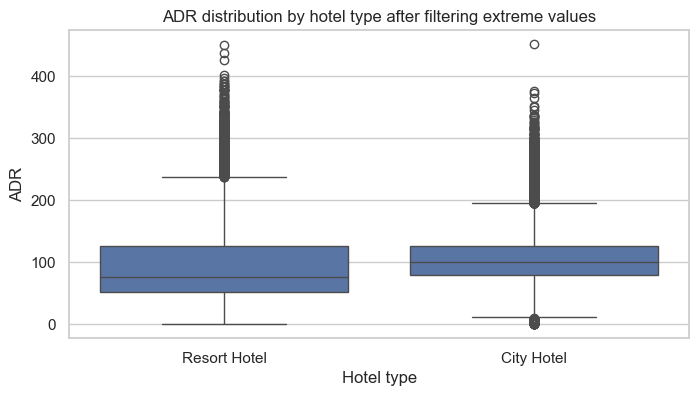

In [56]:
df_adr = df[(df["adr"] > 0) & (df["adr"] < 500)].copy()

plt.figure(figsize=(8, 4))
sns.boxplot(data=df_adr, x="hotel", y="adr")
plt.title("ADR distribution by hotel type after filtering extreme values")
plt.xlabel("Hotel type")
plt.ylabel("ADR")
plt.show()

<Figure size 800x400 with 0 Axes>

<Axes: xlabel='is_canceled', ylabel='adr'>

Text(0.5, 1.0, 'ADR by cancellation status and hotel type')

Text(0.5, 0, 'Canceled (0 = no, 1 = yes)')

Text(0, 0.5, 'ADR')

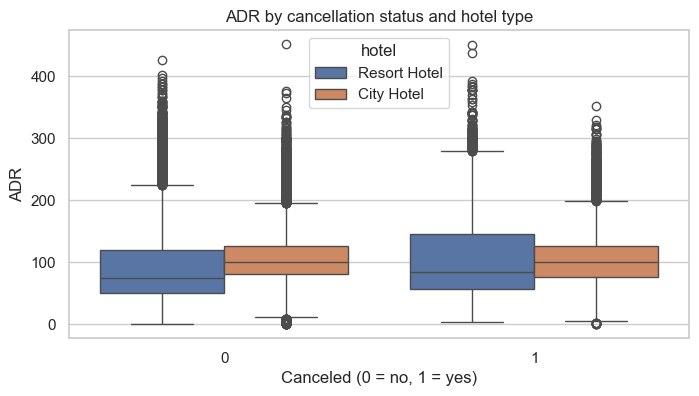

In [57]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_adr, x="is_canceled", y="adr", hue="hotel")
plt.title("ADR by cancellation status and hotel type")
plt.xlabel("Canceled (0 = no, 1 = yes)")
plt.ylabel("ADR")
plt.show()

After filtering extreme ADR values, City Hotel generally shows higher ADR than Resort Hotel. 
For Resort Hotel, canceled bookings appear to have slightly higher and more variable ADR than non-canceled bookings. 
For City Hotel, the difference between canceled and non-canceled bookings is less clear. 
Therefore, ADR may be associated with cancellation, but the pattern is not strong enough to conclude that higher prices directly lead to cancellation.

<Figure size 700x400 with 0 Axes>

<Axes: xlabel='is_canceled', ylabel='total_nights'>

Text(0.5, 1.0, 'Stay duration by cancellation status')

Text(0.5, 0, 'Canceled (0 = no, 1 = yes)')

Text(0, 0.5, 'Total nights')

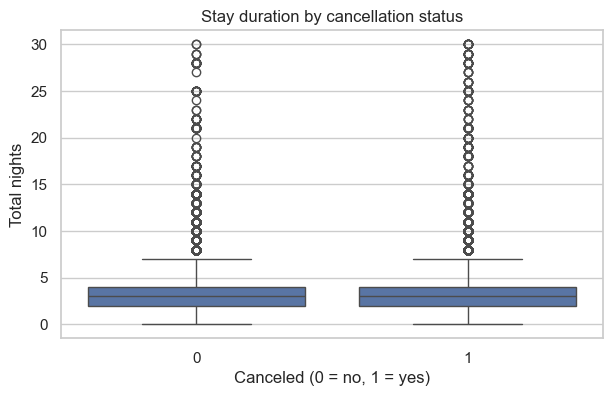

In [58]:
df_nights = df[df["total_nights"] <= 30].copy()

plt.figure(figsize=(7, 4))
sns.boxplot(data=df_nights, x="is_canceled", y="total_nights")
plt.title("Stay duration by cancellation status")
plt.xlabel("Canceled (0 = no, 1 = yes)")
plt.ylabel("Total nights")
plt.show()

The distribution of stay duration is similar for canceled and non-canceled bookings. 
The median number of nights does not appear to differ strongly between the two groups. 
Therefore, stay duration seems less informative than lead time or market segment for explaining cancellations in this EDA.

## Part 10 — Synthesis: from observations to insights

EDA is not finished when the plots are drawn. You must now summarize your main findings.

### Example synthesis


**Finding 1:**

Observation: Cancellation rate increases strongly with lead time, from less than 10% for bookings made within one week to more than 67% for bookings made more than one year in advance.

Possible explanation: Plans made far in advance are more likely to change.

Business implication: Hotels should monitor long-lead-time bookings more carefully.

**Finding 2:**

Observation: City Hotel has a higher cancellation rate than Resort Hotel in every lead-time group and in every month.

Possible explanation: City Hotel may serve different customers, booking channels, and travel purposes.

Business implication: Cancellation management strategies should be adapted to hotel type.

**Finding 3:**

Observation: `Non Refund` bookings have an extremely high cancellation rate, around 99.4%.

Possible explanation: This result is counter-intuitive and probably reflects confounding. `Non Refund` bookings are strongly associated with Groups, Offline TA/TO, longer lead times, and City Hotel.

Business implication: Hotels should not interpret deposit type alone. They should combine deposit type with market segment, lead time, and customer type to identify high-risk bookings.

Limitations:

This EDA shows associations, not causal effects. Some variables are strongly correlated with each other. Some categories have very small sample sizes, such as `Undefined` market segment and `Refundable` deposit type. The dataset covers only two hotels during a specific period, so conclusions may not generalize to all hotels.



### Final questions — possible answers

1. Variables such as `lead_time`, `hotel`, `market_segment`, `deposit_type`, and `customer_type` appear associated with cancellation.
2. City Hotel and Resort Hotel can show different cancellation levels and seasonal patterns.
3. A hotel manager may monitor bookings with long lead time, high-risk market segments, and specific deposit/customer types.
4. The main limitations are that EDA is descriptive, not causal; some variables are correlated with each other; and some categories may have small sample sizes.


In [59]:
summary_by_lead = lead_cancel.copy()
summary_by_lead

summary_by_hotel = hotel_cancel.copy()
summary_by_hotel

segment_cancel.head()
deposit_cancel
customer_cancel

,lead_time_group,cancellation_rate,num_bookings
0,0-7,0.096323,19746
1,8-30,0.278639,18960
2,31-90,0.376984,29553
3,91-180,0.447105,26439
4,181-365,0.554540,21544
5,365+,0.676620,3148


,hotel,cancellation_rate,num_bookings
0,City Hotel,0.417270,79330
1,Resort Hotel,0.277634,40060


,cancellation_rate,num_bookings
market_segment,,
Undefined,1.000000,2
Groups,0.610620,19811
Online TA,0.367211,56477
Offline TA/TO,0.343160,24219
Aviation,0.219409,237


,cancellation_rate,num_bookings
deposit_type,,
Non Refund,0.993624,14587
No Deposit,0.283770,104641
Refundable,0.222222,162


,cancellation_rate,num_bookings
customer_type,,
Transient,0.407463,89613
Contract,0.309617,4076
Transient-Party,0.254299,25124
Group,0.102253,577


## End of Lab